# **Ensemble Models**

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

---


1. **One Decision Tree** : one person giving an answer

2. **Random Forrest** : Multiple Decision Tree working together.

3. **Boosting** : One model makes mistakes the next tree focuses on the mistakes made by the previous tree.

---

**Classfication**:

*   Random Forrest Classifier
*   AdaBoosting
*   Gradient Boosting



**Regression**:

*   Random Forrest Regressor
*   Linear Reg
*   Gradient Boosting
*   Decision Tree Reg


# **1. Importing Models**

In [9]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, RandomForestRegressor, GradientBoostingRegressor


from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor


from sklearn.linear_model import LogisticRegression, LinearRegression

from sklearn.neighbors import KNeighborsClassifier


from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline

# **2. Loading Dataset**



In [10]:
churn_df = pd.read_csv(r"C:\Users\Akanksha\Downloads\OneDrive_1_6-26-2026\telecom_churn_clean.csv")

In [11]:
churn_df.shape

(3333, 20)

In [12]:
adv_df = pd.read_csv(r"C:\Users\Akanksha\Downloads\OneDrive_1_6-26-2026\advertising_and_sales_clean.csv")

In [13]:
adv_df.shape

(4546, 5)

In [14]:
churn_df.head()

,Unnamed: 0,account_length,area_code,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,customer_service_calls,churn
0,0,128,415,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,1,107,415,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,2,137,415,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,3,84,408,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,4,75,415,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0


In [15]:
churn_df.columns

Index(['Unnamed: 0', 'account_length', 'area_code', 'international_plan',
       'voice_mail_plan', 'number_vmail_messages', 'total_day_minutes',
       'total_day_calls', 'total_day_charge', 'total_eve_minutes',
       'total_eve_calls', 'total_eve_charge', 'total_night_minutes',
       'total_night_calls', 'total_night_charge', 'total_intl_minutes',
       'total_intl_calls', 'total_intl_charge', 'customer_service_calls',
       'churn'],
      dtype='object')

In [16]:
churn_df['churn'].value_counts()

churn
0    2850
1     483
Name: count, dtype: int64

In [17]:
churn_df = churn_df.drop("Unnamed: 0",axis=1)

In [18]:
churn_df.shape

(3333, 19)

# **3. Spliting x and y**


In [19]:
x = churn_df.drop("churn", axis=1)

In [20]:
y = churn_df['churn']

# Train Test Split

In [21]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [22]:
x_train.shape

(2666, 18)

# **4. Building Models**

In [23]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=1
)

rf.fit(x_train,y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [24]:
print("training accuracy",rf.score(x_train,y_train))
print("testing accuracy",rf.score(x_test,y_test))

training accuracy 1.0
testing accuracy 0.9460269865067467


# **5. Predictions**

In [25]:
y_pred = rf.predict(x_test)
y_pred[:5]

array([1, 0, 0, 0, 0])

# **6. Confusion Matrix**

In [26]:
confusion_matrix(y_test,y_pred)

array([[563,   7],
       [ 29,  68]])

In [27]:
cm = confusion_matrix(y_test,y_pred)

In [28]:
cmd = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['No Churn','Churned'])

Text(0.5, 1.0, 'Confusion Matrix')

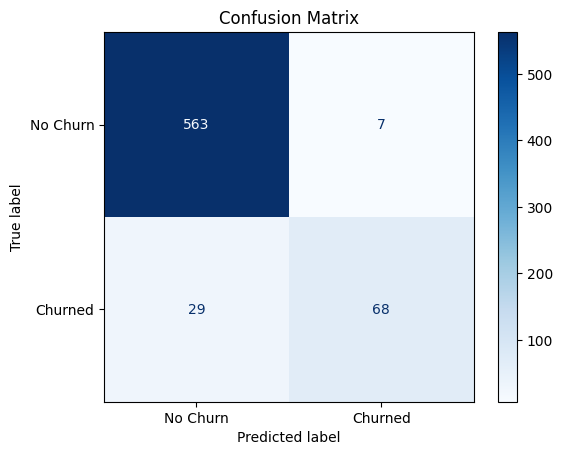

In [29]:
cmd.plot(cmap='Blues')
plt.title("Confusion Matrix")

# **7. Classification Report**

In [30]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97       570
           1       0.91      0.70      0.79        97

    accuracy                           0.95       667
   macro avg       0.93      0.84      0.88       667
weighted avg       0.94      0.95      0.94       667



# **8. Business Problem**

In churn model recall matters more than precison.

Missing a churner(**False Negative**) is expensive bcz that customer permantently leaves.

False flagging a loyal customer (**False Positive**) will just leads to you offering them any kind of offer or deal to retain them.

# **9. Number of Trees**

In [31]:
tc = [10,20,50,100,150,200,250,300]

ts = []

for n in tc:
  model = RandomForestClassifier(
    n_estimators=n,
    random_state=42,
    n_jobs=-1
  )

  cv_score = cross_val_score(model,x_train,y_train,cv=5).mean()
  ts.append(cv_score)

In [32]:
print(ts)

[np.float64(0.9388627723788041), np.float64(0.9508639528919056), np.float64(0.9546170007940356), np.float64(0.9557427043587635), np.float64(0.9572436424450675), np.float64(0.9583693460097955), np.float64(0.9579948141745895), np.float64(0.9576195796530135)]


In [33]:
print(cv_score)

0.9576195796530135


Text(0, 0.5, 'accuracy')

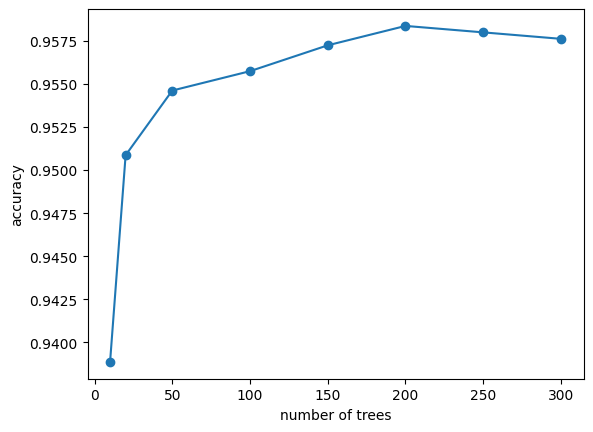

In [34]:
plt.plot(tc,ts,marker='o')
plt.xlabel("number of trees")
plt.ylabel("accuracy")

Number of tres in random forrest : 150 (0.957)

# **10. Features**

In [35]:
fi = pd.Series(rf.feature_importances_,index=x.columns)

In [36]:
fi.sort_values(ascending=False).head(10)

total_day_charge          0.152002
total_day_minutes         0.135371
customer_service_calls    0.128387
international_plan        0.073324
total_eve_minutes         0.064309
total_eve_charge          0.060361
total_intl_calls          0.052330
total_intl_charge         0.042975
total_intl_minutes        0.038738
total_night_charge        0.034439
dtype: float64

In [37]:
top_f = fi.sort_values(ascending=True).tail(10)

Text(0.5, 1.0, 'Feature Importance : Churn Prediction')

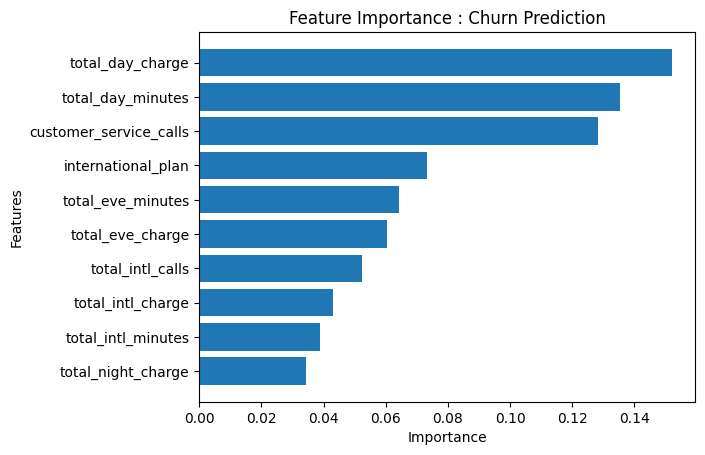

In [38]:
plt.barh(top_f.index,top_f.values)
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance : Churn Prediction")

# **11. Boosting**

> **AdaBoost Classifer**

In [39]:
ada = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

In [40]:
ada.fit(x_train,y_train)

,estimator,None
,n_estimators,100
,learning_rate,0.1
,algorithm,'deprecated'
,random_state,42


In [41]:
print("training",ada.score(x_train,y_train))
print("testing",ada.score(x_test,y_test))

training 0.8582145536384096
testing 0.8590704647676162


In [42]:
y_pred_ada = ada.predict(x_test)

In [43]:
y_pred_ada[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

## ADA Confusion Matrix Display

In [44]:
cm_ada = confusion_matrix(y_test,y_pred_ada)

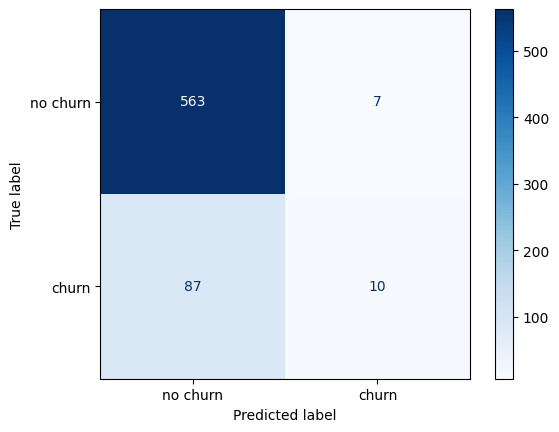

In [45]:
cmd = ConfusionMatrixDisplay(confusion_matrix=cm_ada,display_labels=['no churn','churn'])
cmd.plot(cmap='Blues')

In [46]:
print(classification_report(y_test,y_pred_ada))

              precision    recall  f1-score   support

           0       0.87      0.99      0.92       570
           1       0.59      0.10      0.18        97

    accuracy                           0.86       667
   macro avg       0.73      0.55      0.55       667
weighted avg       0.83      0.86      0.81       667



# **12. Gradient Boosting**

In [47]:
gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate = 0.1,
    max_depth=3,
    random_state=42
)

In [48]:
gb.fit(x_train,y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,200
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [49]:
print("training",gb.score(x_train,y_train))
print("testing",gb.score(x_test,y_test))

training 0.9819954988747187
testing 0.9445277361319341


In [50]:
y_pred_gb = gb.predict(x_test)

In [51]:
cm_gb = confusion_matrix(y_test,y_pred_gb)

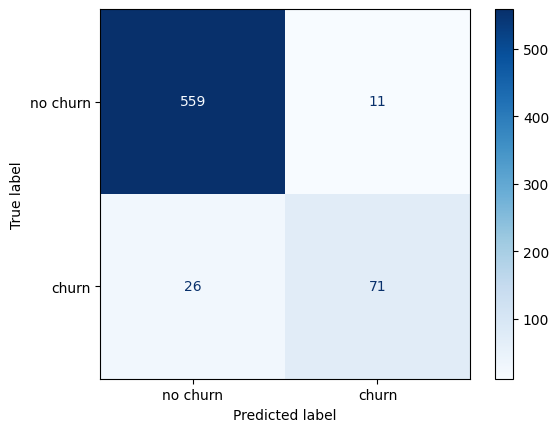

In [52]:
cmd = ConfusionMatrixDisplay(confusion_matrix=cm_gb,display_labels=['no churn','churn'])
cmd.plot(cmap='Blues')

# **13. GridSearch**

In [53]:
gb = {
    'n_estimators' : [100,300],
    'learning_rate' : [0.03,0.15],
    'max_depth' : [3,7]
}

In [54]:
gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

In [55]:
gb_grid.fit(x_train,y_train)

,estimator,GradientBoost...ndom_state=42)
,param_grid,"{'learning_rate': [0.03, 0.15], 'max_depth': [3, 7], 'n_estimators': [100, 300]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'log_loss'


In [56]:
print(gb_grid.best_params_)

{'learning_rate': 0.15, 'max_depth': 7, 'n_estimators': 300}


In [57]:
pd.DataFrame(gb_grid.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_learning_rate,param_max_depth,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,3.955644,0.505205,0.015012,0.004336,0.03,3,100,"{'learning_rate': 0.03, 'max_depth': 3, 'n_est...",0.936330,0.962477,0.954972,0.949343,0.936210,0.947866,0.010345,8
1,12.492065,0.654896,0.026226,0.005047,0.03,3,300,"{'learning_rate': 0.03, 'max_depth': 3, 'n_est...",0.943820,0.956848,0.956848,0.951220,0.958724,0.953492,0.005452,3
2,10.830967,0.196960,0.018885,0.002093,0.03,7,100,"{'learning_rate': 0.03, 'max_depth': 7, 'n_est...",0.947566,0.951220,0.958724,0.951220,0.945591,0.950864,0.004488,7
3,28.775933,1.540488,0.028652,0.005454,0.03,7,300,"{'learning_rate': 0.03, 'max_depth': 7, 'n_est...",0.949438,0.951220,0.960600,0.953096,0.949343,0.952739,0.004163,6
4,3.974500,0.105546,0.016550,0.008422,0.15,3,100,"{'learning_rate': 0.15, 'max_depth': 3, 'n_est...",0.941948,0.958724,0.956848,0.956848,0.954972,0.953868,0.006077,2
5,10.724849,0.989943,0.024705,0.011134,0.15,3,300,"{'learning_rate': 0.15, 'max_depth': 3, 'n_est...",0.945693,0.953096,0.960600,0.958724,0.945591,0.952741,0.006301,5
6,8.507501,1.101323,0.017491,0.004153,0.15,7,100,"{'learning_rate': 0.15, 'max_depth': 7, 'n_est...",0.949438,0.949343,0.962477,0.956848,0.949343,0.953490,0.005345,4
7,20.200154,0.966565,0.015762,0.004151,0.15,7,300,"{'learning_rate': 0.15, 'max_depth': 7, 'n_est...",0.949438,0.954972,0.969981,0.960600,0.947467,0.956492,0.008153,1


In [58]:
y_pred_gb_grid = gb_grid.predict(x_test)

In [59]:
cm_gb_grid = confusion_matrix(y_test,y_pred_gb_grid)

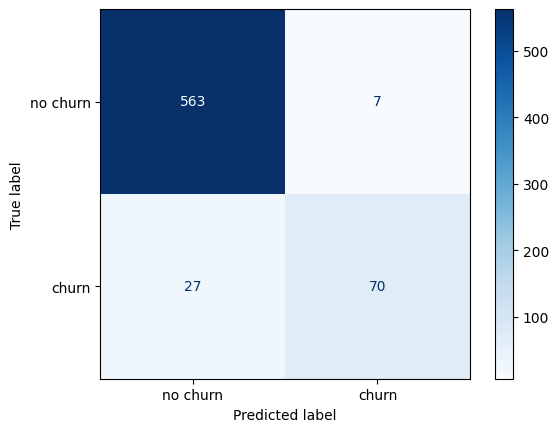

In [60]:
cmd = ConfusionMatrixDisplay(confusion_matrix=cm_gb_grid,display_labels=['no churn','churn'])
cmd.plot(cmap='Blues')

# **14. Deployment**

In [61]:
final_model = rf

In [62]:
x_train.columns

Index(['account_length', 'area_code', 'international_plan', 'voice_mail_plan',
       'number_vmail_messages', 'total_day_minutes', 'total_day_calls',
       'total_day_charge', 'total_eve_minutes', 'total_eve_calls',
       'total_eve_charge', 'total_night_minutes', 'total_night_calls',
       'total_night_charge', 'total_intl_minutes', 'total_intl_calls',
       'total_intl_charge', 'customer_service_calls'],
      dtype='object')

In [63]:
deploy_cols = [
    'total_day_charge',
    'total_day_minutes',
    'customer_service_calls',
    'international_plan',
    'total_eve_minutes',
    'total_eve_charge'
]

In [64]:
x = churn_df[deploy_cols]
y = churn_df['churn']

In [65]:
x_train, x_test, y_train, y_test = train_test_split(
    x,y,test_size=0.2,random_state=42,stratify=y
)

In [66]:
final_model = RandomForestClassifier(
    n_estimators=200,random_state=42
)

final_model.fit(x_train,y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [67]:
y_pred = final_model.predict(x_test)

In [68]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.92      0.95      0.94       570
           1       0.65      0.55      0.59        97

    accuracy                           0.89       667
   macro avg       0.79      0.75      0.76       667
weighted avg       0.88      0.89      0.89       667



In [69]:
final_model_b = RandomForestClassifier(
    n_estimators=300,random_state=42,class_weight='balanced'
)

final_model_b.fit(x_train,y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [70]:
y_pred_b = final_model_b.predict(x_test)

In [71]:
print(classification_report(y_test,y_pred_b))

              precision    recall  f1-score   support

           0       0.93      0.95      0.94       570
           1       0.64      0.58      0.61        97

    accuracy                           0.89       667
   macro avg       0.79      0.76      0.77       667
weighted avg       0.89      0.89      0.89       667



In [72]:
churn_prob = final_model_b.predict_proba(x_test)

In [73]:
prob_df = pd.DataFrame(churn_prob, columns=['no_churn','churn_p'])

In [74]:
prob_df.head()

,no_churn,churn_p
0,0.623333,0.376667
1,0.933333,0.066667
2,0.866667,0.133333
3,0.996667,0.003333
4,1.000000,0.000000


In [75]:
prob_df['churn_pct'] = prob_df['churn_p'] * 100
prob_df['churn_pct'] = prob_df['churn_pct'].round(2)

In [76]:
prob_df.head()

,no_churn,churn_p,churn_pct
0,0.623333,0.376667,37.67
1,0.933333,0.066667,6.67
2,0.866667,0.133333,13.33
3,0.996667,0.003333,0.33
4,1.000000,0.000000,0.00


In [77]:
prob_df['actual'] = y_test.values

In [78]:
prob_df['prediction_30'] = np.where(prob_df['churn_p'] >= 0.30,1,0)

In [79]:
prob_df[['actual','prediction_30','churn_p']].head(100)

,actual,prediction_30,churn_p
0,1,1,0.376667
1,0,0,0.066667
2,0,0,0.133333
3,0,0,0.003333
4,0,0,0.000000
...,...,...,...
95,0,0,0.000000
96,0,0,0.020000
97,0,0,0.016667
98,0,0,0.003333


In [80]:
print(classification_report(y_test,prob_df['prediction_30']))

              precision    recall  f1-score   support

           0       0.94      0.91      0.92       570
           1       0.55      0.67      0.60        97

    accuracy                           0.87       667
   macro avg       0.74      0.79      0.76       667
weighted avg       0.88      0.87      0.88       667



In [81]:
final_model = final_model_b

In [82]:
final_threshold = 0.30

In [83]:
import joblib

In [84]:
joblib.dump(final_model,'churn_model.pkl')
joblib.dump(deploy_cols,'model_cols.pkl')
joblib.dump(final_threshold,'threshold.pkl')

['threshold.pkl']

In [85]:
loaded_columns = joblib.load('model_cols.pkl')

In [86]:
sample_customer = pd.DataFrame([[40,230,4,1,210,20]],columns=loaded_columns)

In [87]:
print(sample_customer)

   total_day_charge  total_day_minutes  customer_service_calls  \
0                40                230                       4   

   international_plan  total_eve_minutes  total_eve_charge  
0                   1                210                20  


In [88]:
loaded_model = joblib.load('churn_model.pkl')

In [89]:
churn_pbl = loaded_model.predict_proba(sample_customer)[0][1]

churn_pbl

np.float64(0.26)

In [90]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib

model = joblib.load('churn_model.pkl')
model_columns = joblib.load('model_cols.pkl')
threshold = joblib.load('threshold.pkl')


st.title("Customer Churn Prediction App")


st.write('Enter customer details:')

total_day_charge = st.number_input(
    "Total Day Charge",
    min_value=0.0
    value=40.0
)

total_day_min = st.number_input(
    "Total Day Minutes",
    min_value=0.0
    value=230.0
)

customer_service_calls = st.number_input(
    "Customer Service Calls",
    min_value=0
    value=4
)

int_plan = st.selectbox(
    "International Plan",
    ['Yes','No']
)

if int_plan == 'Yes':
  int_plan = 1
else:
  int_plan = 0


total_eve_min = st.number_input(
    "Total Evening Minutes",
    min_value=0
    value=210
)

total_eve_chg = st.number_input(
    "Total Evening Charge",
    min_value=0
    value=20
)


input_data = pd.DataFrame(
    [[
        total_day_charge,
        total_day_min,
        customer_service_calls,
        int_plan,
        total_eve_min,
        total_eve_chg

    ]], columns = model_columns
)

st.write("Input given data to model:")
st.dataframe(input_data)

if st.button("Predict Churn"):
  churn_pb = model.predict_proba(input_data)[0][1]

  if churn_pb >= threshold:
    prediction = 1
  else:
    prediction = 0


  st.write("Churn Probability:", round(churn_pb * 100,2), "%")
  st.write("Threshold:", threshold)

  if prediction == 1:
    st.error("Final Prediction : customer may churn")
  else:
    st.success("Customer may not churn")

Overwriting app.py


In [91]:
%%writefile requirements.txt

streamlit
pandas
scikit-learn
joblib

Overwriting requirements.txt
